In [1]:
import yaml
import joblib
import re
import datetime as pydt
import operator
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_classic.retrievers import EnsembleRetriever
from langgraph.graph import add_messages, StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from typing import TypedDict, Annotated
from functools import partial
from PIL import Image
from io import BytesIO
from IPython.display import Markdown

from agent_procs import llm_detect_intents, llm_revenue_agent, llm_expenditure_agent, llm_answer_writer

with open('secret.key') as key_file:
    api_key = key_file.readline().strip('\n').strip()

In [2]:
with open('config.yaml', 'rb') as yaml_file:
    config=yaml.safe_load(yaml_file)

In [3]:
embeddings = HuggingFaceEmbeddings(model_name='google/embeddinggemma-300m')

In [4]:
try:
    chroma_vectorstore = Chroma(
        collection_name=config['collection_name'],
        persist_directory=config['chroma_dir'],
        embedding_function=embeddings,
        create_collection_if_not_exists=False
    )
    dense_retriever = chroma_vectorstore.as_retriever(
        search_type='similarity',
        search_kwargs={'k': config['retrieval_k']},
    )
    with open(config['bm25_index_path'], 'rb') as bm25_file:
        sparse_retriever = joblib.load(bm25_file)

    hybrid_retriever = EnsembleRetriever(
        retrievers=[dense_retriever, sparse_retriever],
        weights=[config['vector_search_weightage'], (1-config['vector_search_weightage'])],
    )
except:
    print('[Error] Vector database or bm25 index missing, please run part1_1 script first')

In [5]:
def get_process_trace(node, summary):
    trace = {
        'node': node,
        'timestamp': pydt.datetime.now().isoformat(timespec='seconds'),
        'summary': summary
    }
    return trace

def print_trace_list(trace_list):
    if not trace_list:
        print('No process trace records found')
    else:
        for step, trace in enumerate(trace_list):
            print(f'[Step {step} - Node: {trace['node']} - Time: {trace['timestamp']}]')
            print(trace['summary'])
            print('')

In [6]:
class State(TypedDict):
    user_query: str
    detected_intents: str
    supervisor_routing: list[str]

    revenue_agent_answer: str
    expenditure_agent_answer: str

    final_answer: str

    trace: Annotated[list[dict], operator.add]

In [ ]:
def node_supervisor(state:State, llm)->dict:
    user_query = state['user_query']

    detected_intents = llm_detect_intents(llm, user_query)
    routing = []
    if detected_intents.requires_revenue_agent:
        routing.append('revenue_agent')
    if detected_intents.requires_expenditure_agent:
        routing.append('expenditure_agent')

    process_trace = get_process_trace(
        node='node_supervisor',
        summary=f"""
        Detected intents: {detected_intents.intent_summary}.
        Routing: {routing}
        """
    )
        
    return_state = {
        'user_query': user_query,
        'detected_intents' : detected_intents.intent_summary,
        'supervisor_routing': routing,
        'final_answer': '',
        'trace': [process_trace]
    }
    
    if not routing:
        return_state['final_answer'] = ['NO_INTENT_FOUND', 
                                        {'text':'No query related to government revenue or expenditure detected.'}]
    
    return return_state

def supervisor_route_condition(state:State) -> list[str]:
    if not state['supervisor_routing']:
        return [END]
    else:
        return state['supervisor_routing']

def node_revenue_agent(state:State, llm, rag_retriever)->dict:
    user_query = state['user_query']

    agent_response = llm_revenue_agent(llm, user_query, rag_retriever)

    process_trace = get_process_trace(
        node='node_revenue_agent',
        summary='Revenue agent RAG analysis findings completed'
    )
    return {
        'revenue_agent_answer': agent_response.content,
        'trace': [process_trace]
    }

def node_expenditure_agent(state:State, llm, rag_retriever)->dict:
    user_query = state['user_query']

    agent_response = llm_expenditure_agent(llm, user_query, rag_retriever)

    process_trace = get_process_trace(
        node='node_expenditure_agent',
        summary='Revenue agent RAG analysis findings completed'
    )
    return {
        'expenditure_agent_answer': agent_response.content,
        'trace': [process_trace]
    }

def node_answer_writer(state:State, llm)->dict:
    user_query = state['user_query']
    revenue_agent_answer = state.get('revenue_agent_answer', '[No findings given]')
    expenditure_agent_answer = state.get('expenditure_agent_answer', '[No findings given]')

    final_answer = llm_answer_writer(llm, user_query, revenue_agent_answer, expenditure_agent_answer)

    if revenue_agent_answer == '[No findings given]':
        revenue_answer_trace = '[No findings given]'
    else:
        revenue_answer_trace = '[RAG analysis findings received]'
    if expenditure_agent_answer == '[No findings given]':
        expenditure_answer_trace = '[No findings given]'
    else:
        expenditure_answer_trace = '[RAG analysis findings received]'

    process_trace = get_process_trace(
        node='node_answer_writer',
        summary=f"""
        Revenue: {revenue_answer_trace}
        Expenditure: {expenditure_answer_trace}
        Final answer completed
        """
    )
    return {
        'final_answer': final_answer.content,
        'trace': [process_trace]
    }

In [8]:
def build_graph(llm):
    g = StateGraph(State)

    g.add_node('supervisor', partial(node_supervisor, llm=llm))
    g.add_node('revenue_agent', partial(node_revenue_agent, llm=llm, rag_retriever=hybrid_retriever))
    g.add_node('expenditure_agent', partial(node_expenditure_agent, llm=llm, rag_retriever=hybrid_retriever))
    g.add_node('final_answer_writer', partial(node_answer_writer, llm=llm))

    g.add_edge(START, 'supervisor')
    g.add_conditional_edges('supervisor', supervisor_route_condition, ['revenue_agent', 'expenditure_agent', END])
    g.add_edge('revenue_agent', 'final_answer_writer')
    g.add_edge('expenditure_agent', 'final_answer_writer')
    g.add_edge('final_answer_writer', END)

    return g.compile()

In [ ]:
def extract_final_answer(final_state):
    if isinstance(final_state['final_answer'], list):
        final_answer = final_state['final_answer'][1]['text']
    else:
        # TODO - very rare bug where agent returns different final_answer structure in AIMessage - no list, no signature
        if isinstance(final_state['final_answer'], str):
            llm_text = final_state['final_answer']
        else:
            llm_text = final_state['final_answer'][1]['text']
        final_answer = ''
        answer_text = re.search(r"<answer>(.*?)</answer>", llm_text, re.DOTALL)
        if not answer_text:
            final_answer += '[Error] LLM did not return in <answer> tags as prompted\n'
            final_answer += llm_text
        else:
            final_answer = answer_text.group(1).strip()
    return final_answer

In [10]:
llm = ChatAnthropic(
    model_name='claude-sonnet-5',
    max_tokens=4096,
    timeout=30,
    max_retries=2,
    anthropic_api_key=api_key
)

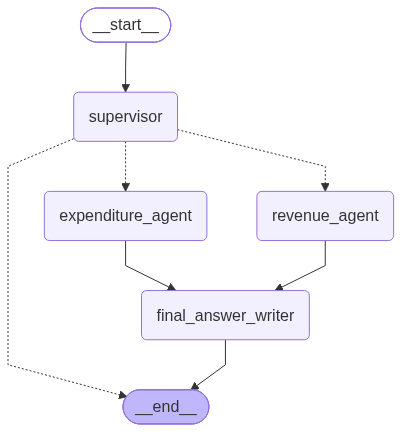

In [11]:
app = build_graph(llm)
image = Image.open(BytesIO(app.get_graph(xray=True).draw_mermaid_png()))
display(image)


In [12]:
query = 'What are the key government revenue streams, and how will the Budget for the Future Energy Fund be supported?'

final_state = app.invoke({'user_query': query})

display(Markdown(extract_final_answer(final_state)))

<answer>

## Key Government Revenue Streams (FY2024)

Based on the Revenue Agent's findings, the following revenue-related items are explicitly discussed in *fy2024_analysis_of_revenue_and_expenditure.pdf*:

1. **Statutory Boards' Contributions** — Estimated to **decrease by $0.4 billion (58.8%) to $0.3 billion** in FY2024, "due to expected lower contributions from the Monetary Authority of Singapore" (Page 13).

2. **Capitalisation of Nationally Significant Infrastructure** — Projected at **$4.1 billion** for FY2024, which is **$0.6 billion (17.1%) higher** than the Revised FY2023 figure of **$3.5 billion**. This covers capitalised expenditure on the North South Corridor, Deep Tunnel Sewerage System, Cross Island Line, and Jurong Region Line (Page 15, with FY2023 comparison on Page 7).

3. **SINGA Interest Costs and Loan Expenses** (a financing-related item tied to borrowing) — Projected at **$0.4 billion** for FY2024, **$0.2 billion (78.6%) higher** than the Revised FY2023 figure of **$0.2 billion**, "due to additional interest costs from additional SGS (Infrastructure) that will be raised in FY2024" (Page 15).

Note: The Revenue Agent flagged that further historical revenue data exists in "Tables 3.2a and 3.2b in the Statistical Annex" (Page 13), but the details of these tables were not included in the provided context, so a fully comprehensive revenue picture is not available.

## Future Energy Fund — Budget Support (FY2024)

Both agents agree on the following:

- **Amount:** The Government will establish the Future Energy Fund with an **initial injection of $5.0 billion** ($5,000 million) in Estimated FY2024, "to invest in critical infrastructure for the energy transition" (Page 18).
- This is confirmed in **Table 2.1 (Budget for FY2024)**, Page 16, row 30: Future Energy Fund, Estimated FY2024 = **$5.00 billion**.
- It is also listed in **Table 2.4 (Top-ups to Endowment and Trust Funds in FY2024)**, Page 20, row 1: Future Energy Fund, Estimated FY2024 = **$5,000 million** (consistent with the $5.0 billion figure, expressed in millions).
- This top-up is part of the broader **$20.4 billion in total Fund top-ups** committed under Budget 2024 (Page 18), which also includes:
 - GST Voucher Fund: $6.0 billion
 - Edusave Endowment Fund: $2.0 billion
 - National Productivity Fund: $2.0 billion
 - Financial Sector Development Fund: $2.0 billion
 - National Research Fund: $1.8 billion
 - PWCS Fund: $1.0 billion
 - Skills Development Fund: $500 million
 - Public Transport Fund: $50 million
 - Legal Aid Fund: $2 million

**How it is supported:** The Expenditure Agent characterizes this as "a new endowment/trust fund in Budget 2024, funded via a one-time Government expenditure injection — not through a recurring revenue stream." Both agents agree that the provided context **does not specify the exact revenue source** (e.g., tax collections, NIRC, or other specific receipts) used to finance this $5.0 billion top-up. It is described only as part of the Government's overall Fund top-ups/Special Transfers for Budget 2024, drawn from overall fiscal resources, with no further breakdown of the financing mechanism available in the given context.

**Summary reconciliation:** Both agents concur precisely on the Future Energy Fund figures and its classification as an expenditure-side fund top-up rather than a distinct revenue stream. Neither agent found information in the provided context linking specific revenue streams (e.g., Statutory Boards' Contributions, Capitalisation of Infrastructure, or SINGA-related items) directly to financing the Future Energy Fund.
</answer>

In [13]:
print_trace_list(final_state['trace'])

[Step 0 - Node: node_supervisor - Time: 2026-07-19T21:44:34]

        Detected intents: User wants to know the key government revenue streams and how the Future Energy Fund's budget will be supported (likely through revenue sources and/or expenditure allocations)..
        Routing: ['revenue_agent', 'expenditure_agent']
        

[Step 1 - Node: node_expenditure_agent - Time: 2026-07-19T21:44:47]
Revenue agent RAG analysis findings completed

[Step 2 - Node: node_revenue_agent - Time: 2026-07-19T21:44:53]
Revenue agent RAG analysis findings completed

[Step 3 - Node: node_answer_writer - Time: 2026-07-19T21:45:06]

        Revenue: [RAG analysis findings received]
        Expenditure: [RAG analysis findings received]
        Final answer completed
        



In [14]:
query = 'Where does money come from for the government in 2024'

final_state = app.invoke({'user_query': query})

display(Markdown(extract_final_answer(final_state)))

<answer>
Based on the Revenue Agent's findings from Singapore's **FY2024 Analysis of Revenue and Expenditure** (the Expenditure Agent returned no findings, so this answer covers revenue/inflows only):

**Total Operating Revenue**
- FY2024 Operating Revenue is estimated at **$108.6 billion (15.1% of GDP)**, an increase of $4.3 billion (4.2%) over the Revised FY2023 Operating Revenue (Source: fy2024_analysis_of_revenue_and_expenditure.pdf, Page 13).

**Key Components of Operating Revenue (FY2024 estimates vs. FY2023):**

| Revenue Source | FY2024 Estimate | Change from FY2023 | Reason |
|---|---|---|---|
| Personal Income Tax | $18.1 billion | +$0.5 billion (3.1%) | Nominal wage growth in 2023 and increase in the top marginal tax rate effective Year of Assessment 2024 |
| Assets Taxes (Property Tax & Estate Duty) | $6.7 billion | +$0.8 billion (12.8%) | Higher Property Tax rates effective 1 January 2024 and higher property Annual Values |
| Motor Vehicle Tax | $2.8 billion | +$0.2 billion (9.3%) | Expected further recovery in COE quota supply |
| Statutory Boards' Contributions | $0.3 billion | −$0.4 billion (58.8%) | Expected lower contributions from the Monetary Authority of Singapore |

(Source: fy2024_analysis_of_revenue_and_expenditure.pdf, Page 13)

**Additional Inflows Beyond Operating Revenue (used in the overall fiscal calculation):**
- **Net Investment Returns Contribution (NIRC)**: $23.5 billion — investment income from reserves that supplements the budget.
- **Capitalisation of Nationally Significant Infrastructure**: $4.1 billion — an accounting inflow offsetting infrastructure capital spending.

These figures feed into the overall fiscal picture: a **basic deficit of $6.1 billion (0.8% of GDP)** is estimated for FY2024. After factoring in Top-ups to Endowment and Trust Funds of $20.4 billion, NIRC of $23.5 billion, Capitalisation of Nationally Significant Infrastructure of $4.1 billion, and SINGA Interest Costs and Loan Expenses of $0.4 billion, the estimated **Overall Fiscal Position for FY2024 is a surplus of $0.8 billion (0.1% of GDP)** (Source: fy2024_analysis_of_revenue_and_expenditure.pdf, Page 13).

**Limitations of Available Data:**
The retrieved context does not include specific FY2024 figures for other major revenue categories such as **Corporate Income Tax, GST (Goods and Services Tax), Customs Duties, or Vehicle Quota Premiums** — though the Glossary on Page 36 conceptually defines Customs Duties and Assets Taxes. The source document references "Tables 3.2a and 3.2b in the Statistical Annex" for more granular historical revenue data, but these tables were not part of the retrieved findings.

Additionally, since the Expenditure Agent provided no findings, this answer cannot address how revenue is spent or the composition of government expenditure for FY2024.
</answer>

In [15]:
print_trace_list(final_state['trace'])

[Step 0 - Node: node_supervisor - Time: 2026-07-19T21:45:37]

        Detected intents: User wants to know the sources of government revenue/income for the year 2024..
        Routing: ['revenue_agent']
        

[Step 1 - Node: node_revenue_agent - Time: 2026-07-19T21:45:56]
Revenue agent RAG analysis findings completed

[Step 2 - Node: node_answer_writer - Time: 2026-07-19T21:46:06]

        Revenue: [RAG analysis findings received]
        Expenditure: [No findings given]
        Final answer completed
        



In [16]:
query = 'Where are the largest cost savings possible in 2023'

final_state = app.invoke({'user_query': query})

display(Markdown(extract_final_answer(final_state)))

<answer>
The Revenue Agent returned no findings for this query, so the answer below is based solely on the Expenditure Agent's findings from *fy2024_analysis_of_revenue_and_expenditure.pdf*.

**No dollar-quantified "cost savings" table exists in the available context.** The only information on reduced/lower expenditure for FY2023 is qualitative, appearing on Page 6 of *fy2024_analysis_of_revenue_and_expenditure.pdf*, which notes that increases in expenditure elsewhere were "partly offset by lower expenditure" in three areas:

- **Ministry of Manpower (MOM):** lower expenditure "due to lower utilisation for the Jobs Growth Incentive."
- **Ministry of Education (MOE):** lower expenditure "on manpower."
- **Ministry of Home Affairs (MHA):** lower expenditure due to "lower manpower costs, expected delays in IT projects, and savings in systems maintenance."

None of these three areas is accompanied by a specific dollar figure in the source, so it is not possible to say definitively which ministry had the single largest cost saving.

A related but distinct figure appears on Page 13 of the same report: **Statutory Boards' Contributions are estimated to decrease by $0.4 billion (58.8%) to $0.3 billion**, due to expected lower contributions from the Monetary Authority of Singapore. However, this is a **revenue** decline (lower contributions received by the government), not an expenditure cost saving, so it should not be conflated with spending reductions — though it is the single largest quantified percentage decline found in the context.

**Conclusion:** Based on the available findings, the largest *qualitatively identified* areas of reduced FY2023 expenditure are at MOM, MOE, and MHA (Page 6, fy2024_analysis_of_revenue_and_expenditure.pdf), but no specific dollar amounts are provided for these savings, so the "largest" cannot be precisely ranked. No revenue-side findings were available to supplement this analysis. If a precise dollar breakdown of ministry-level savings is needed, the provided context does not contain it, and further source data would be required.
</answer>

In [17]:
print_trace_list(final_state['trace'])

[Step 0 - Node: node_supervisor - Time: 2026-07-19T21:46:08]

        Detected intents: User wants to identify where the largest cost savings can be achieved in government expenditure for 2023..
        Routing: ['expenditure_agent']
        

[Step 1 - Node: node_expenditure_agent - Time: 2026-07-19T21:46:24]
Revenue agent RAG analysis findings completed

[Step 2 - Node: node_answer_writer - Time: 2026-07-19T21:46:31]

        Revenue: [No findings given]
        Expenditure: [RAG analysis findings received]
        Final answer completed
        



In [18]:
query = 'What is the most important policy in 2024'

final_state = app.invoke({'user_query': query})

display(Markdown(extract_final_answer(final_state)))

<answer>
**Important caveat:** Neither the Revenue Agent nor the Expenditure Agent found any explicit statement in the source document (Singapore's *FY2024 Analysis of Revenue and Expenditure*, presented 2024-02-16) that ranks or designates a single "most important policy" for 2024. The document does not use prioritization language of this kind. What follows is a synthesis of the most prominent, quantitatively significant fiscal items and the qualitative policy framing that both agents identified — offered as the closest objective proxy for "importance," not as a stated fact.

**Overarching policy framing (both agents cite this identically):**
> "Building on Forward SG, Budget 2024 will strengthen our economy, social compact, and resilience, to secure Singapore's future amidst a more troubled and competitive world." (Source: fy2024_analysis_of_revenue_and_expenditure.pdf, Page 21)

**Key fiscal facts supporting this framing:**

1. **Operating Revenue**: Estimated FY2024 Operating Revenue is **$108.6 billion (15.1% of GDP)**, an increase of **$4.3 billion (4.2%)** over Revised FY2023 (Page 13, Revenue Agent).

2. **Basic fiscal deficit before top-ups**: A basic deficit of **$6.1 billion (0.8% of GDP)** is estimated for FY2024 before other adjustments (Page 13, Expenditure Agent).

3. **Overall Fiscal Position**: After factoring in Top-ups to Endowment and Trust Funds ($20.4 billion), NIRC ($23.5 billion), Capitalisation of Nationally Significant Infrastructure ($4.1 billion), and SINGA Interest Costs and Loan Expenses ($0.4 billion), the estimated **Overall Fiscal Position for FY2024 is a surplus of $0.8 billion (0.1% of GDP)** — a shift from a deficit of $3.57 billion in Revised FY2023 (Page 13, 16, both agents).

4. **Net Investment Returns Contribution (NIRC)**: Estimated FY2024 NIRC is **$23.5 billion**, up **$0.6 billion (2.6%)** from Revised FY2023 — the largest single fiscal inflow funding the Budget (Page 15, both agents).

5. **Top-ups to Endowment and Trust Funds**: Total **$20.4 billion** for FY2024 (Table 2.4, Page 20), with the largest allocations being:
   - **Future Energy Fund: $5,000 million** — the single largest specific top-up (Page 20, Table 2.4, row 1; also Page 16, Table 2.1, row 30)
   - **National Productivity Fund: $2,000 million** (Page 20, row 4)
   - **Progressive Wage Credit Scheme Fund: $1,000 million** (Page 20, row 6)
   - **Skills Development Fund: $500 million** (Page 20, row 7)

6. **Capitalisation of Nationally Significant Infrastructure**: Projected at **$4.1 billion** for FY2024 (up **$0.6 billion, 17.1%**, from Revised FY2023), funding projects such as the North South Corridor, Deep Tunnel Sewerage System, Cross Island Line, and Jurong Region Line (Page 15, both agents).

7. **SINGA Interest Costs and Loan Expenses**: Projected at **$0.4 billion** for FY2024 (up **$0.2 billion, 78.6%**, from Revised FY2023), due to additional SGS (Infrastructure) borrowing (Page 15, both agents).

**Conclusion:** If "most important" is inferred from the single largest dedicated fund allocation disclosed for FY2024, the **Future Energy Fund top-up of $5,000 million ($5.00 billion)** — reflecting a policy emphasis on energy transition — stands out as the largest specific expenditure item. Alternatively, from a fiscal-strategy perspective, the shift from a basic deficit to an **overall surplus of $0.8 billion**, enabled largely by NIRC ($23.5 billion) and the endowment/trust fund top-ups ($20.4 billion), represents the most consequential fiscal outcome of Budget 2024. However, since neither the Revenue nor the Expenditure Agent found the source explicitly ranking any single policy as "most important," this conclusion should be treated as an inference based on scale, not a stated fact in the document.
</answer>

In [19]:
print_trace_list(final_state['trace'])

[Step 0 - Node: node_supervisor - Time: 2026-07-19T21:46:34]

        Detected intents: The user is asking about the most important government policy in 2024, which is broad and could relate to both government spending initiatives and revenue-related measures..
        Routing: ['revenue_agent', 'expenditure_agent']
        

[Step 1 - Node: node_expenditure_agent - Time: 2026-07-19T21:46:51]
Revenue agent RAG analysis findings completed

[Step 2 - Node: node_revenue_agent - Time: 2026-07-19T21:46:52]
Revenue agent RAG analysis findings completed

[Step 3 - Node: node_answer_writer - Time: 2026-07-19T21:47:06]

        Revenue: [RAG analysis findings received]
        Expenditure: [RAG analysis findings received]
        Final answer completed
        



In [29]:
query = 'If inflation surges much higher than expected, how can the government offset that'

final_state = app.invoke({'user_query': query})

display(Markdown(extract_final_answer(final_state)))

Based on the findings from both agents, **the provided context (fy2024_analysis_of_revenue_and_expenditure.pdf) does not contain an explicit forward-looking policy, mechanism, or contingency plan describing how the government would offset a scenario where inflation surges much higher than currently expected.** Both agents independently confirmed this gap — the documents present historical/estimated budget figures for FY2018–FY2024, not prospective inflation-shock response strategies.

However, the documents do describe how the government has responded to *actual* inflationary and cost-of-living pressures already experienced in FY2023, which may be indirectly relevant to your question:

1. **Cost-of-Living (COL) Support Package**: Special Transfers were revised to **$27.2 billion** in FY2023, **$7.6 billion (38.7%) higher** than the Estimated FY2023 figure. This increase was driven partly by "additional requirements for the Cost-of-Living (COL) Support Package announced in September 2023" (Source: fy2024_analysis_of_revenue_and_expenditure.pdf, Page 7).

2. **Majulah Package Fund**: A top-up to this fund was made "to boost the retirement and healthcare adequacy of Singaporeans," announced at the National Day Rally 2023, and was cited as a factor contributing to higher Total Expenditure in Revised FY2023 (Source: Page 5/7).

3. **Higher expenditure absorbing inflation costs**: Operating Expenditure was revised to **$85.4 billion**, **$1.7 billion (2.1%) higher** than Estimated FY2023, with the increase attributed in part to MINDEF spending due to "heightened inflationary pressures," alongside catching up on COVID-deferred projects and SAF digitalisation (Source: Page 6). This shows inflation being absorbed into higher budget outlays rather than a discrete "offset" instrument.

4. **Revenue buoyancy as a partial offset**: Revised FY2023 Operating Revenue reached **$104.3 billion**, **$7.6 billion (7.9%) higher** than the Estimated figure, driven mainly by stronger-than-expected economic growth and higher tax collections — Corporate Income Tax (+$4.1bn/17.0%), Other Taxes (+$2.1bn/32.3%), Vehicle Quota Premiums (+$0.8bn/20.1%), Personal Income Tax (+$0.7bn/4.1%), Assets Taxes (+$0.4bn/6.7%), Betting Taxes (+$0.3bn/10.8%), partially offset by lower GST (-$1.0bn/5.8%) (Source: Page 5). This revenue buoyancy helped fund the higher expenditure noted above.

5. Additional reference figures from the Revenue Agent: Net Investment Returns Contribution (Estimated FY2024: $23.5 billion, Page 15) and Overall Budget Surplus/Deficit figures (Pages 16, 24, 25) are noted in the documents, though no explicit link is made between these and an inflation-offset strategy.

**Important caveat**: These are historical/realized budget adjustments made in response to inflationary and cost-of-living pressures already experienced in FY2023 — they are not a stated policy for handling a *future*, larger-than-expected inflation surge. If you are looking for a specific contingency mechanism (e.g., reserve draws, additional NIRC contributions, or new tax measures) designed for a bigger inflation shock, **that information is not present in the supplied context**, and neither agent found sufficient data to answer this specific hypothetical.

In [30]:
print_trace_list(final_state['trace'])

[Step 0 - Node: node_supervisor - Time: 2026-07-19T21:50:36]

        Detected intents: The user is asking how the government can offset the impact of a significant, unexpected inflation surge—likely through fiscal measures involving both increased spending (e.g., subsidies, cost adjustments) and revenue adjustments (e.g., taxes, levies)..
        Routing: ['revenue_agent', 'expenditure_agent']
        

[Step 1 - Node: node_expenditure_agent - Time: 2026-07-19T21:50:54]
Revenue agent RAG analysis findings completed

[Step 2 - Node: node_revenue_agent - Time: 2026-07-19T21:50:48]
Revenue agent RAG analysis findings completed

[Step 3 - Node: node_answer_writer - Time: 2026-07-19T21:51:05]

        Revenue: [RAG analysis findings received]
        Expenditure: [RAG analysis findings received]
        Final answer completed
        



In [31]:
query = 'What to get for dinner'

final_state = app.invoke({'user_query': query})

display(Markdown(extract_final_answer(final_state)))

No query related to government revenue or expenditure detected.

In [32]:
print_trace_list(final_state['trace'])

[Step 0 - Node: node_supervisor - Time: 2026-07-19T21:51:08]

        Detected intents: The user's query "What to get for dinner" is unrelated to government finances, revenue, or expenditure. It does not pertain to government spending, budget, taxes, or any related financial topics..
        Routing: []
        



In [17]:
# print(f'[supervisor_routing] {final_state['supervisor_routing']}')
# print(f'[detected_intents] {final_state['detected_intents']}')
# print(f'[revenue_agent_answer] {final_state['revenue_agent_answer']}')
# print(f'[expenditure_agent_answer] {final_state['expenditure_agent_answer']}')
# print(f'[final_answer] {final_state['final_answer']}')